In [3]:
pip install mesa==1.2.1


  Using cached Mesa-1.2.1-py3-none-any.whl.metadata (7.2 kB)
Using cached Mesa-1.2.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: mesa
    Found existing installation: Mesa 3.5.1
    Uninstalling Mesa-3.5.1:
      Successfully uninstalled Mesa-3.5.1
Note: you may need to restart the kernel to use updated packages.


In [23]:
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.time import SimultaneousActivation
from mesa.datacollection import DataCollector
import random
import math
import numpy as np

# =====================================================
#   AGENTKLASSE — Consument
# =====================================================

class Consument(Agent):
    """Een inwoner van Rotterdam met individueel recyclinggedrag."""

    # -------------------------------------------------
    #  Modelconstanten & parameters
    # -------------------------------------------------
    INIT_RECYCLING_PERCENTAGE = 0.5
    GEWICHT_PER_STUK = 0.24
    AFGEDANKT_PER_JAAR = 50
    AFGEDANKT_PER_MAAND = AFGEDANKT_PER_JAAR / 12

    BELOONING_PER_STUK = 0.0
    BELOONING_GROEISNELHEID = 0.8
    BELOONING_MIDDEN = 3.0

    MAX_EFFECT_GEMAK = 0.15
    GEMAK_MIDDELPUNT = 4
    GEMAK_SCHERPTE = 0.6
    AFSTAND_INVLOED = 1.5

    BIAS_CORRECTIE = 0.05  # kalibratie zodat basis ±50%

    # -------------------------------------------------
    #  Initialisatie
    # -------------------------------------------------
    def __init__(self, unique_id, model, locatie):
        super().__init__(unique_id, model)
        self.locatie = locatie

        self.milieubewustzijn = random.uniform(0.25, 0.6)
        self.prijsgevoeligheid = random.uniform(0.2, 0.8)
        self.gemaksgevoeligheid = random.uniform(0.3, 0.7)
        self.sociale_druk_gevoeligheid = random.uniform(0.05, 0.4)

        self.sociale_druk = 0
        self.aantal_gerecycled = 0
        self.aantal_weggegooid = 0
        self.afgedankt_textiel = self.AFGEDANKT_PER_MAAND
        self.afstand_inzamelpunt = None

    # -------------------------------------------------
    #  Gedragsregels
    # -------------------------------------------------
    def bepaal_recycling_kans(self):
        basis = self.INIT_RECYCLING_PERCENTAGE

        # Beloningseffect
        beloning_factor = 1 / (1 + math.exp(
            -self.BELOONING_GROEISNELHEID * (self.BELOONING_PER_STUK - self.BELOONING_MIDDEN)
        ))
        reward_effect = self.prijsgevoeligheid * 0.3 * beloning_factor

        # Gemakseffect
        gemak_effect = self.model.logistiek_effect(
            len(self.model.inzamelpunten),
            self.MAX_EFFECT_GEMAK,
            self.GEMAK_MIDDELPUNT,
            self.GEMAK_SCHERPTE
        )

        # Afstandseffect
        if self.afstand_inzamelpunt is not None:
            afstand_factor = min(1, self.afstand_inzamelpunt / (self.model.grid.width / 2)) ** 2
            afstand_penalty = self.gemaksgevoeligheid * self.AFSTAND_INVLOED * afstand_factor
        else:
            afstand_penalty = 0

        gemak_effect_adjusted = max(0, gemak_effect - afstand_penalty)
        sociaal_effect = 0.3 * self.sociale_druk_gevoeligheid * self.sociale_druk

        totale_effecten = reward_effect + gemak_effect_adjusted + sociaal_effect
        return min(1, max(0, basis + totale_effecten - self.BIAS_CORRECTIE))

    def step(self):
        """Voert één gedragscyclus uit voor deze maand."""
        p_recycle = self.bepaal_recycling_kans()
        gerecycled, weggegooid = 0, 0

        for _ in range(int(self.afgedankt_textiel)):
            if random.random() < p_recycle:
                gerecycled += 1
            else:
                weggegooid += 1

        self.aantal_gerecycled += gerecycled
        self.aantal_weggegooid += weggegooid

    def advance(self):
        pass


# =====================================================
#   MODELKLASSE — RotterdamModel
# =====================================================

class RotterdamModel(Model):
    """Mesa‑model van textielinzameling in Rotterdam (base case)."""

    def __init__(self, grid_size=100, aantal_inzamelpunten=4, maanden=12):
        self.grid = MultiGrid(grid_size, grid_size, torus=True)
        self.schedule = SimultaneousActivation(self)
        self.running = True
        self.maanden = maanden
        self.inzamelpunten = self.genereer_inzamelpunten(aantal_inzamelpunten, grid_size)

        # ------------ Agenten aanmaken ------------
        agent_id = 0
        for x in range(grid_size):
            for y in range(grid_size):
                agent = Consument(agent_id, self, (x, y))
                self.schedule.add(agent)
                self.grid.place_agent(agent, (x, y))
                agent.afstand_inzamelpunt = self.afstand_tot_dichtstbijzijnde_inzamelpunt((x, y))
                agent_id += 1

        # ------------ DataCollector met check tegen /0 ------------
        self.datacollector = DataCollector(
            model_reporters={
                "TotaalGerecycled": lambda m: sum(a.aantal_gerecycled for a in m.schedule.agents),
                "TotaalWeggegooid": lambda m: sum(a.aantal_weggegooid for a in m.schedule.agents),
                "RecyclingPercentage": lambda m: (
                    0
                    if sum(a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents) == 0
                    else sum(a.aantal_gerecycled for a in m.schedule.agents)
                         / sum(a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents)
                ),
                "GemiddeldeAfstand": lambda m: np.mean([a.afstand_inzamelpunt for a in m.schedule.agents])
            }
        )

        # Eerste datacollectie (werkt nu zonder fout)
        self.datacollector.collect(self)

    # -------------------------------------------------
    #  Hulpfuncties
    # -------------------------------------------------
    @staticmethod
    def logistiek_effect(x, max_effect, m, k):
        return max_effect / (1 + math.exp(-k * (x - m)))

    @staticmethod
    def afstand(p1, p2):
        return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

    def afstand_tot_dichtstbijzijnde_inzamelpunt(self, agent_loc):
        return min(self.afstand(agent_loc, p) for p in self.inzamelpunten)

    @staticmethod
    def genereer_inzamelpunten(aantal, grid_size):
        locaties = set()
        while len(locaties) < aantal:
            locaties.add((random.randint(0, grid_size - 1), random.randint(0, grid_size - 1)))
        return list(locaties)

    def buren_recycling_ratio(self, agent):
        neighbors = self.grid.get_neighbors(agent.pos, moore=True, include_center=False, radius=1)
        if not neighbors:
            return 0
        recyclende_buren = [n for n in neighbors if n.aantal_gerecycled > n.aantal_weggegooid]
        return len(recyclende_buren) / len(neighbors)

    # -------------------------------------------------
    #  Simulatiestappen
    # -------------------------------------------------
    def step(self):
        for agent in self.schedule.agents:
            agent.sociale_druk = self.buren_recycling_ratio(agent)
        self.schedule.step()
        self.datacollector.collect(self)


# =====================================================
#   SIMULATIE DRAAIEN
# =====================================================

model = RotterdamModel(grid_size=100, aantal_inzamelpunten=4, maanden=12)

for maand in range(model.maanden):
    model.step()

# -----------------------------------------------------
#   RESULTATEN TONEN
# -----------------------------------------------------
data = model.datacollector.get_model_vars_dataframe()
print(data.tail())


    TotaalGerecycled  TotaalWeggegooid  RecyclingPercentage  GemiddeldeAfstand
8             157744            162256             0.492950          29.118413
9             177704            182296             0.493622          29.118413
10            197491            202509             0.493727          29.118413
11            217413            222587             0.494120          29.118413
12            237375            242625             0.494531          29.118413


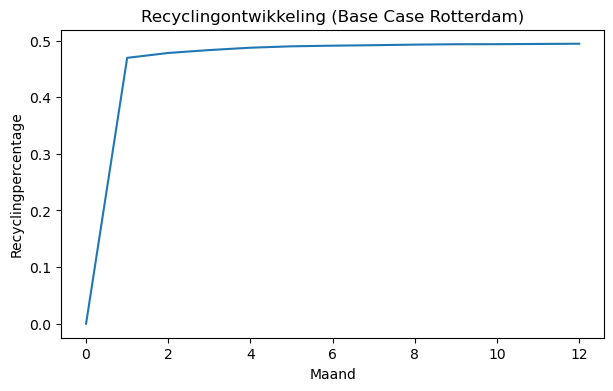

In [25]:
import matplotlib.pyplot as plt

data["RecyclingPercentage"].plot(title="Recyclingontwikkeling (Base Case Rotterdam)", figsize=(7,4))
plt.ylabel("Recyclingpercentage")
plt.xlabel("Maand")
plt.show()
